In [15]:
#| label: import-packages

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import riskfolio as rp
import pandas as pd
from pathlib import Path

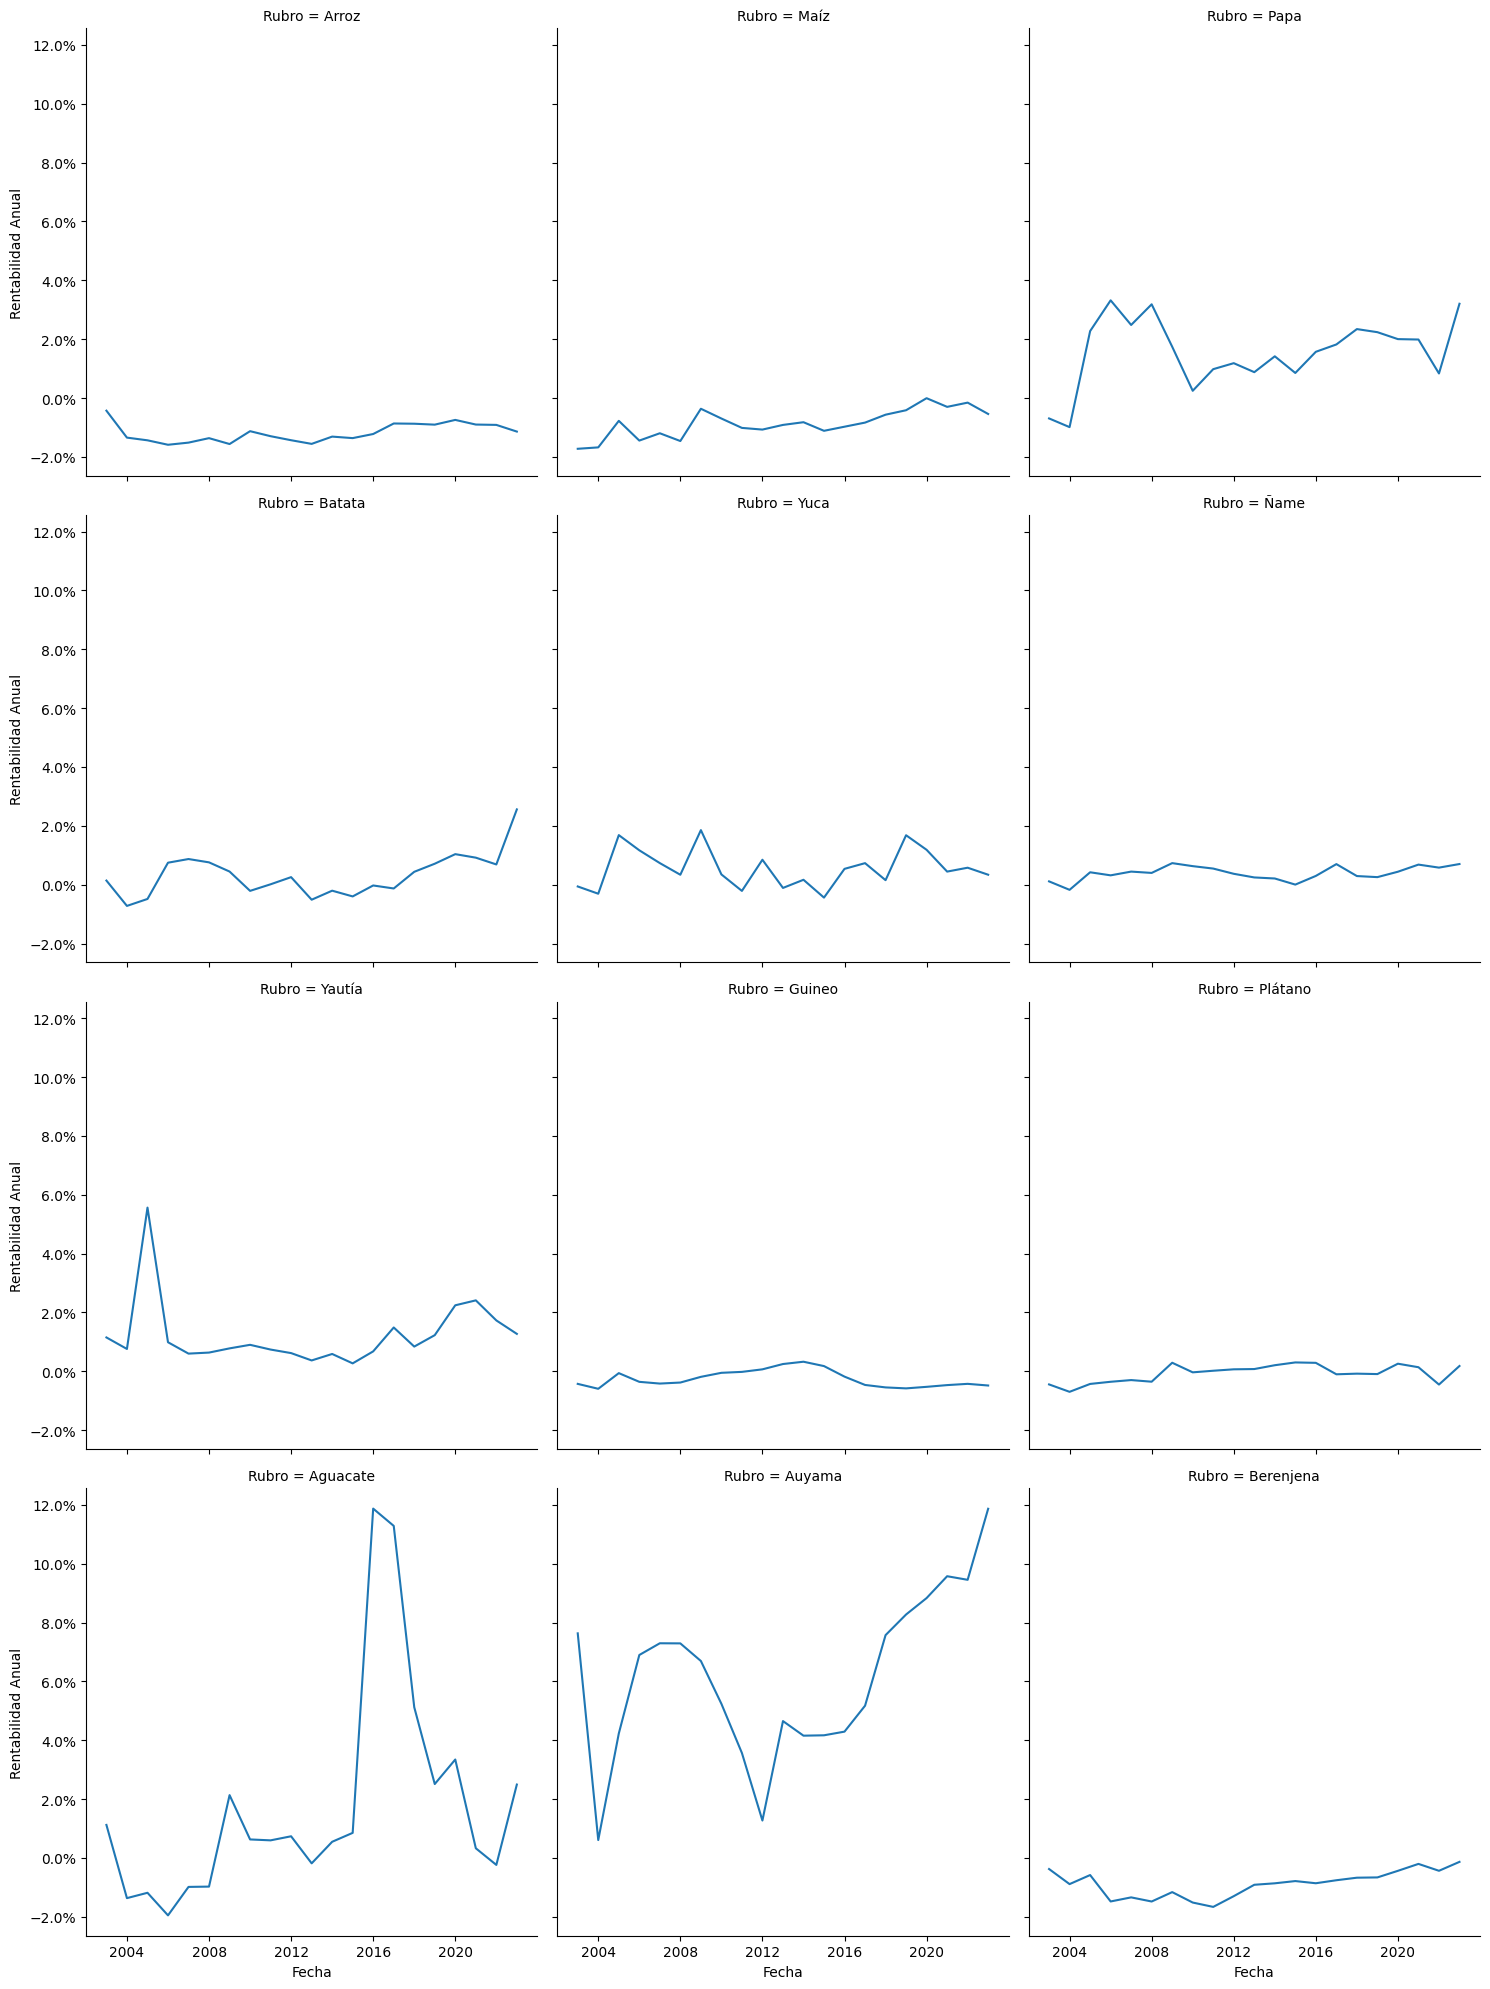

In [16]:
#| label: hue-line-plot
#| fig-cap: "Rentabilidad anual por rubro agrícola"


df = pd.read_excel(Path().cwd().parent / "data" / "dataset.xlsx", sheet_name="data_anual")
df['Fecha'] = pd.to_datetime(df['Fecha'])
df = df[
    (df["Fecha"] >= "2002-01-01") 
]
# Crear el gráfico
g = sns.relplot(
    data=df,
    x="Fecha",
    y="Rentabilidad Anual",
    col="Rubro",
    kind="line",
    col_wrap=3,
)

# Aplicar el formateador de porcentaje a cada subgráfico
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(PercentFormatter())

# Ajustar el diseño
plt.tight_layout()

In [17]:
#| label: y-dataframe
#| tab-cap: "Matriz de rendimientos por rubro"

Y = df.pivot_table(index="Fecha", columns="Rubro", values='Rentabilidad Anual')

display(Y.head())

Rubro,Aguacate,Arroz,Auyama,Batata,Berenjena,Guineo,Maíz,Papa,Plátano,Yautía,Yuca,Ñame
Fecha,,,,,,,,,,,,
2002-12-31,1.122560,-0.429984,7.632047,0.139388,-0.375964,-0.427006,-1.725044,-0.693487,-0.445354,1.150770,-0.061118,0.111642
2003-12-31,-1.365027,-1.345558,0.608851,-0.721773,-0.888504,-0.593890,-1.677293,-0.989070,-0.696857,0.759502,-0.307660,-0.175527
2004-12-31,-1.183266,-1.437202,4.230284,-0.485586,-0.580631,-0.061911,-0.775918,2.274037,-0.428878,5.562082,1.683380,0.420837
2005-12-31,-1.951215,-1.588247,6.896406,0.746568,-1.478060,-0.357606,-1.446040,3.319520,-0.355487,0.987759,1.167513,0.316920
2006-12-31,-0.983526,-1.515451,7.294891,0.871023,-1.339335,-0.416368,-1.197273,2.482070,-0.297831,0.601442,0.733008,0.443948


In [18]:
#| label: port-opt
#| tab-cap: "Pesos optimizados de la cartera"

# Building the portfolio object
port = rp.Portfolio(returns=Y)

# Calculating optimal portfolio

# Select method and estimate input parameters:

method_mu = "hist"  # Method to estimate expected returns based on historical data.
method_cov = "hist"  # Method to estimate covariance matrix based on historical data.

port.assets_stats(method_mu=method_mu, method_cov=method_cov)

# Estimate optimal portfolio:

model = "Classic"  # Could be Classic (historical), BL (Black Litterman) or FM (Factor Model)
rm = "MV"  # Risk measure used, this time will be variance
obj = "Sharpe"  # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
hist = True  # Use historical scenarios for risk measures that depend on scenarios
rf = 0.08  # Risk free rate
l = 0  # Risk aversion factor, only useful when obj is 'Utility'

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T.style.format('{:.2f}%'))


,Aguacate,Arroz,Auyama,Batata,Berenjena,Guineo,Maíz,Papa,Plátano,Yautía,Yuca,Ñame
weights,0.06%,0.00%,0.34%,0.00%,0.00%,0.28%,0.00%,0.02%,0.00%,0.29%,0.00%,0.00%


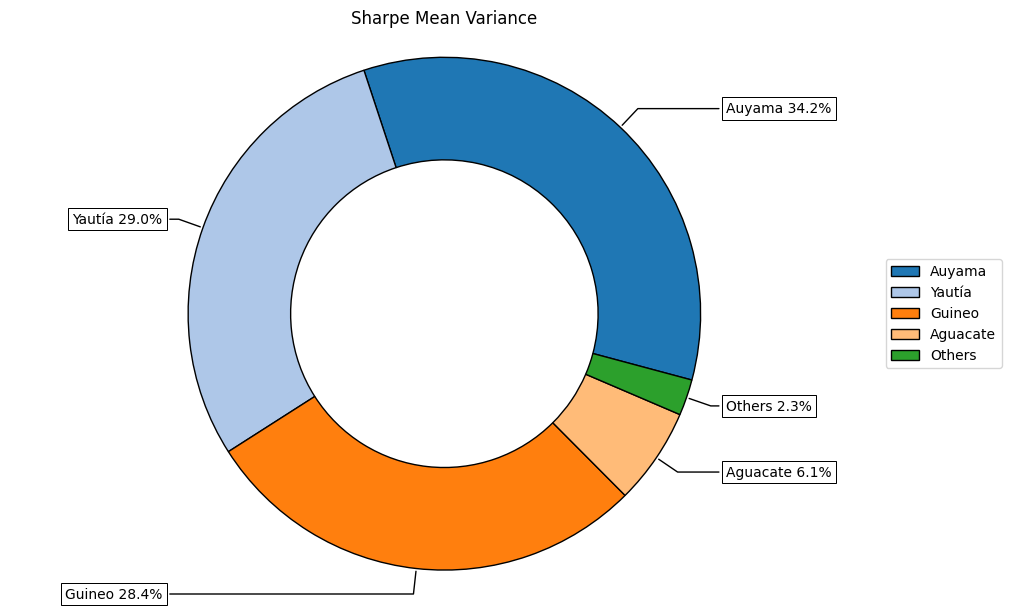

In [19]:
#| label: pie-plot
#| fig-cap: "Ponderación de la cartera óptima"
ax = rp.plot_pie(
    w=w,
    title="Sharpe Mean Variance",
    others=0.05,
    nrow=25,
    cmap="tab20",
    height=6,
    width=10,
    ax=None,
)


In [20]:
#| label: efficient-frontier
#| tab-cap: "Frontera eficiente"

points = 50  # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm=rm, points=points, rf=rf, hist=hist)

display(frontier.T.head())


,Aguacate,Arroz,Auyama,Batata,Berenjena,Guineo,Maíz,Papa,Plátano,Yautía,Yuca,Ñame
0,1.131972e-12,3.351843e-01,1.199798e-12,4.243539e-02,1.660929e-10,0.450169,7.940005e-12,1.129033e-02,1.979427e-11,9.966547e-12,4.990606e-02,0.111015
1,2.432629e-03,3.712861e-02,1.969803e-02,5.697471e-10,1.195241e-02,0.424708,4.235885e-11,1.465488e-10,4.858050e-10,1.559373e-02,2.080951e-02,0.467677
2,9.690727e-03,3.743937e-10,5.249471e-02,6.038558e-10,3.762292e-10,0.438761,1.882778e-10,2.038835e-09,1.982921e-09,4.948958e-02,4.918369e-08,0.449564
3,1.429170e-02,2.531953e-10,7.811385e-02,4.528133e-10,2.561862e-10,0.432403,1.707909e-10,3.954323e-09,1.758327e-09,7.067926e-02,8.967649e-09,0.404512
4,1.829923e-02,1.500566e-10,1.004295e-01,2.808664e-10,1.523501e-10,0.426863,1.145927e-10,4.767372e-09,1.171044e-09,8.913639e-02,4.444402e-09,0.365272


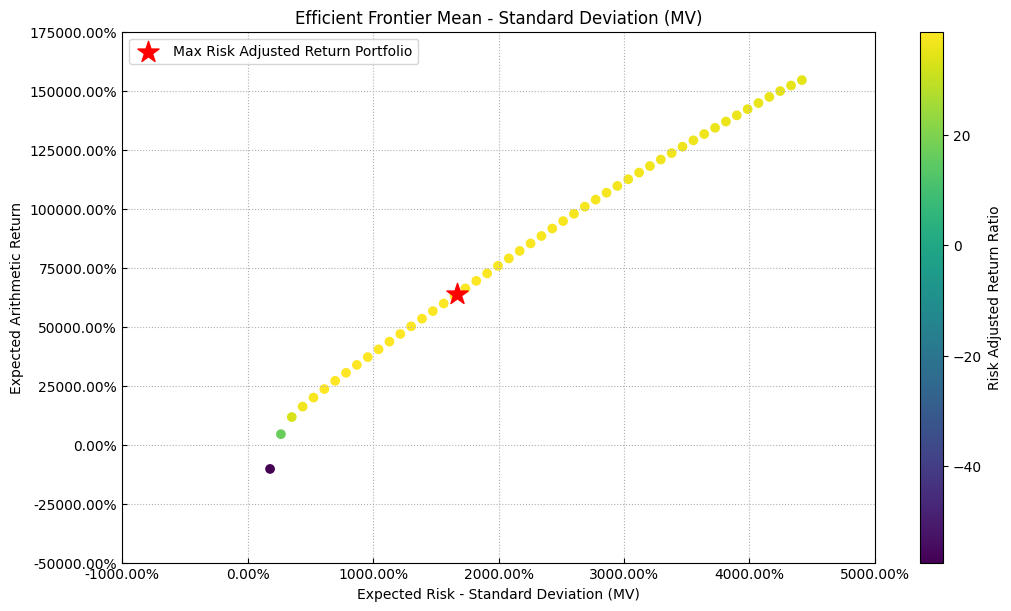

In [22]:
#| label: efficient-frontier-plot
#| fig-cap: "Frontera eficiente"
label = "Max Risk Adjusted Return Portfolio"  # Title of point
mu = port.mu  # Expected returns
cov = port.cov  # Covariance matrix
returns = port.returns  # Returns of the assets

ax= rp.plot_frontier(
    w_frontier=frontier,
    mu=mu,
    cov=cov,
    returns=returns,
    rm=rm,
    rf=rf,
    alpha=0.05,
    w=w,
    label=label,
)

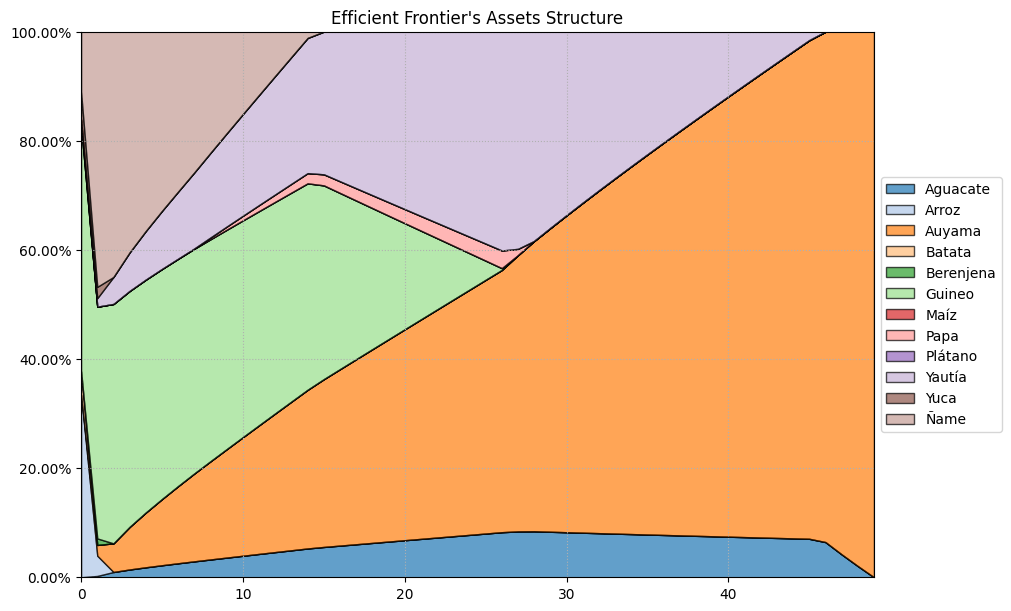

In [14]:
#| label: efficient-frontier-by-risk
#| fig-cap: "Frontera eficiente según el nivel de riesgo"
ax = rp.plot_frontier_area(
    w_frontier=frontier, cmap="tab20", height=6, width=10, ax=None
)


<Axes: title={'center': 'Portfolio Returns Histogram'}, ylabel='Probability Density'>

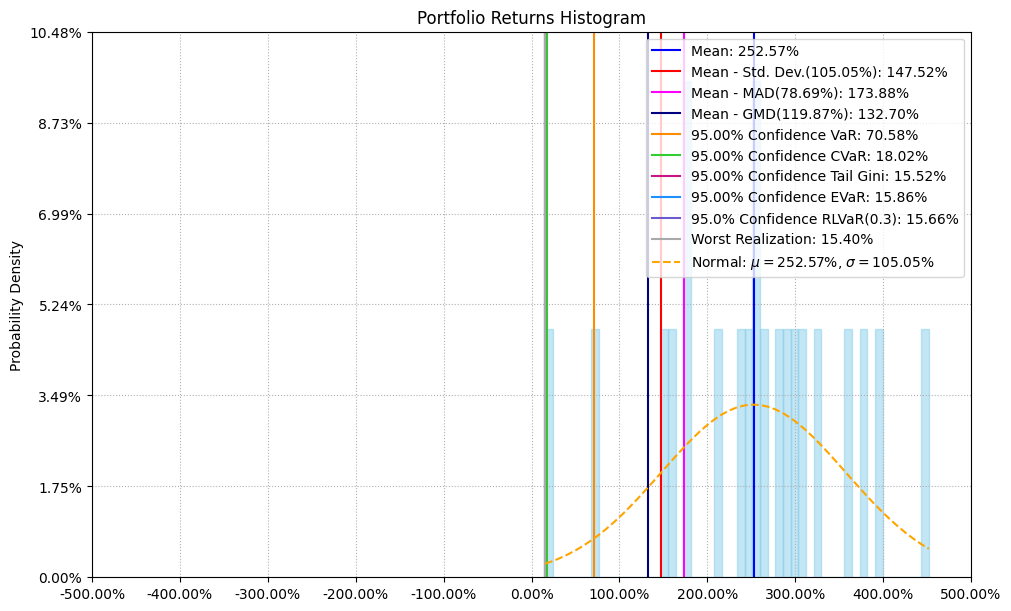

In [15]:
#| label: histogram
#| fig-cap: "Histograma de los rendimientos del portafolio eficiente"
rp.plot_hist(returns=Y, w=w, alpha=0.05, bins=50, height=6, width=10, ax=None)


<Axes: >

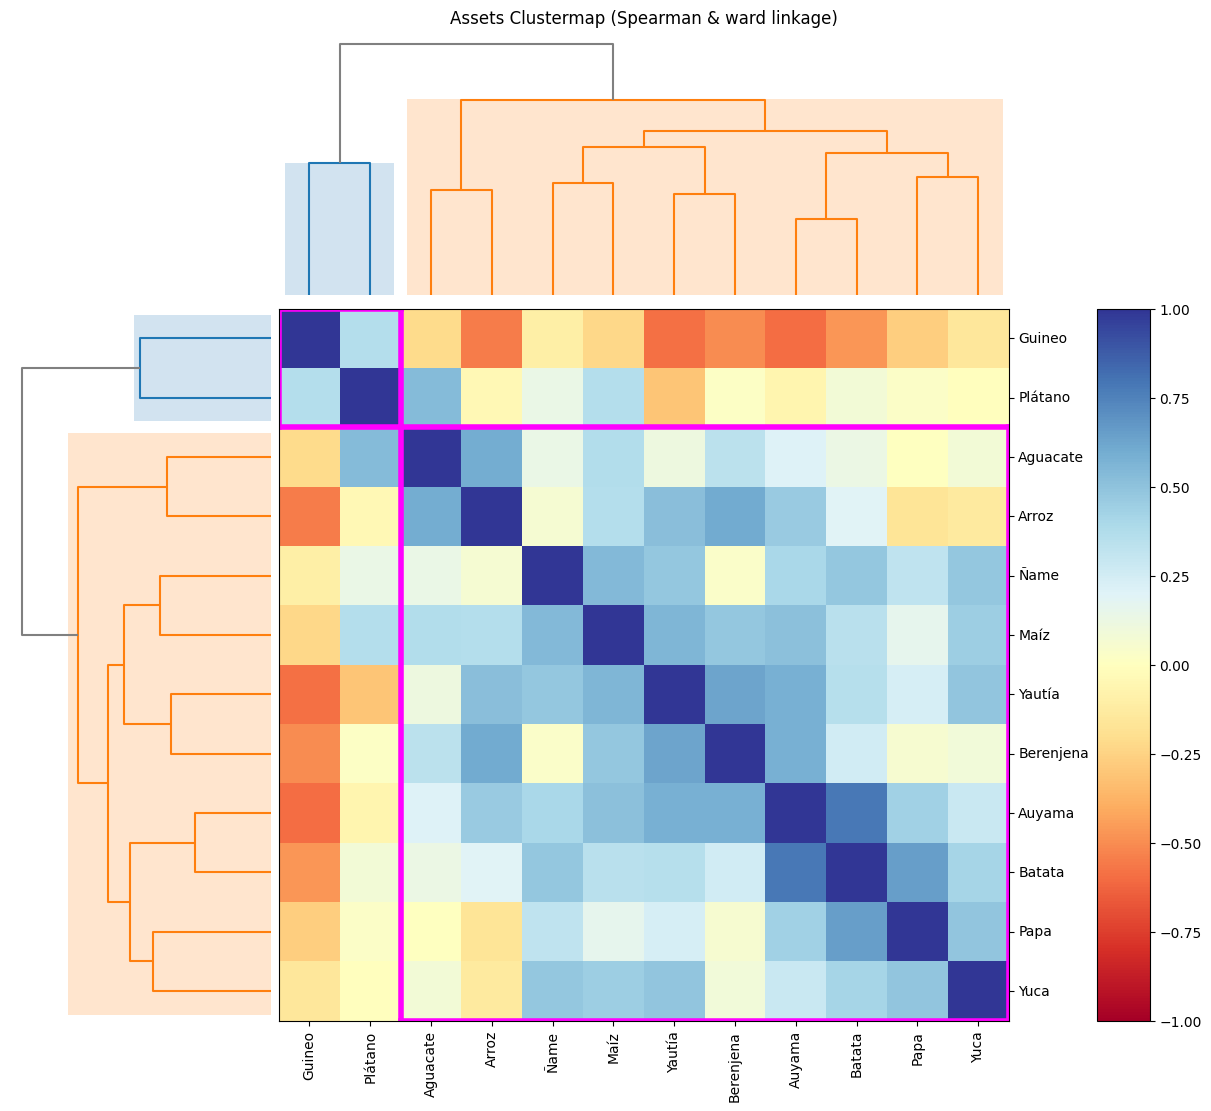

In [16]:
# | label: cluster
# | fig-cap: "Agrupación de los rubros agrícolas"
rp.plot_clusters(
    returns=Y,
    codependence="spearman",
    linkage="ward",
    k=None,
    max_k=10,
    leaf_order=True,
    dendrogram=True,
    ax=None,
)


In [17]:
#| label: wheights-by-risk-metric
#| fig-cap: "Pesos óptimos de la cartera según la métrica de riesgo"

# Risk Measures available:
#
# 'MV': Standard Deviation.
# 'MAD': Mean Absolute Deviation.
# 'MSV': Semi Standard Deviation.
# 'FLPM': First Lower Partial Moment (Omega Ratio).
# 'SLPM': Second Lower Partial Moment (Sortino Ratio).
# 'CVaR': Conditional Value at Risk.
# 'EVaR': Entropic Value at Risk.
# 'WR': Worst Realization (Minimax)
# 'MDD': Maximum Drawdown of uncompounded cumulative returns (Calmar Ratio).
# 'ADD': Average Drawdown of uncompounded cumulative returns.
# 'CDaR': Conditional Drawdown at Risk of uncompounded cumulative returns.
# 'EDaR': Entropic Drawdown at Risk of uncompounded cumulative returns.
# 'UCI': Ulcer Index of uncompounded cumulative returns.

rms = [
    "MV",
    "MAD",
    "MSV",
    "FLPM",
    "SLPM",
    "CVaR",
    "EVaR",
    "WR",
    "MDD",
    "ADD",
    "CDaR",
    "UCI",
    "EDaR",
]

w_s = pd.DataFrame([])

for i in rms:
    w = port.optimization(model=model, rm=i, obj=obj, rf=rf, l=l, hist=hist)
    w_s = pd.concat([w_s, w], axis=1)

w_s.columns = rms
w_s.style.format("{:.2%}").background_gradient(cmap="YlGn")


,MV,MAD,MSV,FLPM,SLPM,CVaR,EVaR,WR,MDD,ADD,CDaR,UCI,EDaR
Aguacate,6.10%,2.01%,2.14%,7.04%,5.57%,0.00%,0.00%,0.00%,4.34%,5.93%,5.22%,4.58%,3.32%
Arroz,0.00%,0.00%,0.00%,1.46%,1.24%,0.00%,0.00%,0.00%,2.54%,1.64%,2.31%,2.60%,2.83%
Auyama,34.25%,13.56%,26.92%,27.86%,18.70%,9.64%,9.64%,9.64%,15.49%,34.39%,21.47%,16.32%,43.12%
Batata,0.00%,0.00%,0.00%,5.54%,5.13%,0.00%,0.00%,0.00%,5.00%,6.49%,5.42%,5.26%,4.26%
Berenjena,0.00%,0.00%,0.00%,2.54%,2.76%,0.00%,0.00%,0.00%,3.28%,2.38%,3.08%,3.30%,3.97%
Guineo,28.41%,61.78%,20.22%,0.61%,3.42%,7.86%,7.86%,7.86%,6.34%,4.79%,5.62%,6.27%,5.40%
Maíz,0.00%,0.00%,0.00%,1.44%,0.34%,0.00%,0.00%,0.00%,2.31%,1.92%,2.23%,2.34%,2.24%
Papa,2.27%,1.52%,0.00%,3.94%,4.00%,0.00%,0.00%,0.00%,3.79%,3.96%,3.98%,3.71%,3.50%
Plátano,0.00%,0.00%,0.00%,0.73%,2.89%,0.00%,0.00%,0.00%,4.88%,3.56%,4.35%,5.06%,4.31%
Yautía,28.96%,4.19%,50.72%,36.51%,40.64%,82.49%,82.49%,82.49%,38.87%,25.46%,34.24%,36.67%,14.67%


<Axes: >

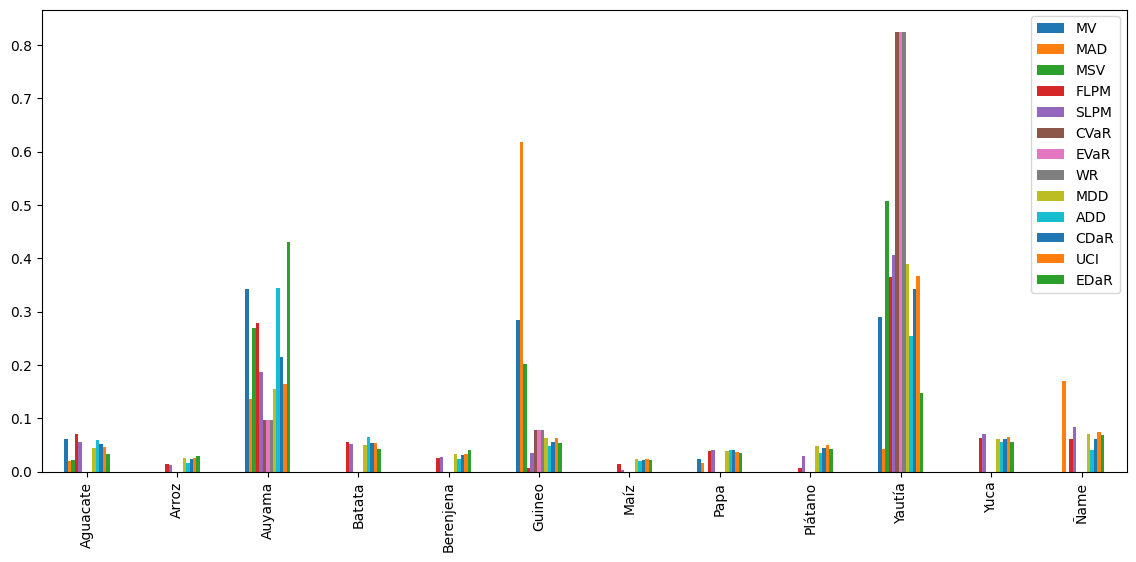

In [18]:
#| label: wheights-by-risk-metric-plot
#| fig-cap: "Pesos por rubro según la métrica de riesgo"

# Plotting a comparison of assets weights for each portfolio

fig = plt.gcf()
fig.set_figwidth(14)
fig.set_figheight(6)
ax = fig.subplots(nrows=1, ncols=1)

w_s.plot.bar(ax=ax)
